# Лабораторная работа 1: Градиентный спуск

Авторы:
1. Ермолин Алексей Владимирович, 465865
2. Галстян Артём Артакович, 465503
3. Железнов Иван Андреевич, 465884

In [1]:
import numpy as np
import pandas as pd
import typing
from typing import Callable
from typing import Literal
from scipy import optimize
import matplotlib.pyplot as plt


pd.set_option('display.precision', 7)      # Точность чисел
pd.set_option('display.width', 120)        # Ширина вывода
pd.set_option('display.max_rows', 100)     # Макс. количество строк (20 → 100)
pd.set_option('display.max_columns', 20)   # Макс. количество столбцов
pd.set_option('display.expand_frame_repr', False)  # Не переносить строки

##Задание 1. Одномерная оптимизация нулевого порядка

В этой части лабораторной работы мы рассмотрим **методы оптимизации нулевого порядка** &ndash; "примитивные" алгоритмы поиска минимума функции, не использующие производные. Здесь мы реализуем 3 таких метода &ndash; метод золотого сечения, метод парабол (в двух реализациях &ndash; используя явную формулу и солвер уравнений) и метод Брента, являющийся их объединением.

### 1. Реализация методов оптимизации

In [2]:
def optimise(f: Callable, a: float, b: float, epsilon:float, N: float, c: float, method: Literal):
  match method:
    case "golden":
      return golden(f, a, b, epsilon, N)
    case "parabole_explicit":
      return parabole_explicit(f, a, b, epsilon, N, c)
    case "parabole_solver":
      return parabole_solver(f, a, b, epsilon, N, c)
    case "brent":
      return brent(f, a, b, epsilon, N, c)
    case "golden_scipy":
      res = optimize.minimize_scalar(f, bracket = (a, c, b), method = "golden", options = {'maxiter': N})
      return (res.x, res.fun)
    case "brent_scipy":
      res = optimize.minimize_scalar(f, bracket = (a, c, b), method = "brent", options = {'maxiter': N})
      return (res.x, res.fun)
    case _:
      raise ValueError("Invalid method. Expected one of: {}".format(methods))

In [3]:
def golden(f, a, b, epsilon, N):
  #init
  K = (5**0.5 - 1) / 2
  L = [0]*(N+2)
  L[0] = b-a
  L[1] = K*L[0]
  x = b-L[1]
  y = a+L[1]
  fx = f(x)
  fy = f(y)

  for k in range(1, N+1):
    L[k+1] = K*L[k]
    if fx < fy:
      b = y
      y = x
      fy = fx
      x = b - L[k+1]
      fx = f(x)
    else:
      a = x
      x = y
      fx = fy
      y = a + L[k+1]
      fy = f(y)
    if L[k+1] < epsilon:
      break
  return (x, fx) if fx < fy else (y, fy)

In [4]:
def parabole_explicit(f, a, b, epsilon, N, c):
  #init
  fa = f(a)
  fb = f(b)
  fc = f(c)

  for k in range(N):
    u = c - ((c-a)**2 * (fc-fb) - (c-b)**2 * (fc-fa)) / (2*((c-a)*(fc-fb) - (c-b)*(fc-fa)))
    fu = f(u)
    if fu < fc and u < c:
      b = c
      fb = fc
      c = u
      fc = fu
    elif fu > fc and u < c:
      a = u
      fa = fu
    elif fu < fc and u > c:
      a = c
      fa = fc
      c = u
      fc = fu
    else:
      b = u
      fb = fu
    if abs(a-c) < epsilon:
      break
  return (a, fa) if fa < fb else (b, fb)

In [5]:
def parabole_solver(f, a, b, epsilon, N, c):
  #init
  fa = f(a)
  fb = f(b)
  fc = f(c)

  for k in range(N):
    #solve system for u
    #system: g(a) = f(a), ...
    A = np.array([[a**2, a, 1],
                  [b**2, b, 1],
                  [c**2, c, 1]])

    p, q, r = np.linalg.solve(A, np.array([fa, fb, fc])) #g(x)=px^2+qx+r

    if abs(p) < 1e-12:  #check for straight line
        u = (a + c) / 2
    else:
        u = -q / (2 * p)

    fu = f(u)
    if fu < fc and u < c:
      b = c
      fb = fc
      c = u
      fc = fu
    elif fu > fc and u < c:
      a = u
      fa = fu
    elif fu < fc and u > c:
      a = c
      fa = fc
      c = u
      fc = fu
    else:
      b = u
      fb = fu
    if abs(a-c) < epsilon:
      break
  return (a, fa) if fa < fb else (b, fb)

In [6]:
def brent(f, a, b, epsilon, N, c):
  #init
  x = c
  w = c
  v = c
  fx = f(c)
  fw = f(c)
  fv = f(c)

  for k in range(N):

    u = np.nan

    #check inequality, try parabole
    if (abs(fx - fw) > 1e-12 and
        abs(fx - fv) > 1e-12 and
        abs(fw - fv) > 1e-12):

      try:
        #solve system for u
        #system: g(a) = f(a), ...
        A = np.array([[x**2, x, 1],
                      [w**2, w, 1],
                      [v**2, v, 1]])

        p, q, r = np.linalg.solve(A, np.array([fx, fw, fv])) #g(x)=px^2+qx+r

        if abs(p) < 1e-12:
          u = (x + w) / 2
        else:
          u = -q / (2 * p)
      except:
        u = np.nan

    #check condition for golden
    if (np.isnan(u) or
      u < a or u > b or
      abs(u - x) > abs(v - b) / 2):

      #golden for larger of [a,x], [x,b]
      if (x - a) > (b - x):
        u = x - (x - a) * (5**0.5 - 1) / 2
      else:
        u = x + (b - x) * (5**0.5 - 1) / 2

    fu = f(u)

    #update variables
    if fu <= fx:
      if u >= x:
        a = x
      else:
        b = x
      v, fv = w, fw
      w, fw = x, fx
      x, fx = u, fu
    else:
      if u >= x:
        b = u
      else:
        a = u
      if fu <= fw or w == x:
        v, fv = w, fw
        w, fw = u, fu
      elif fu <= fv or v == x or v == w:
        v, fv = u, fu

    if abs(b - a) < epsilon:
        break

  return (x, fx)


###2-4. Проверка методов на различных задачах

>Теперь проверим работу различных методов на 5 оптимизационных задачах. Для анализа построим **графики сходимости** каждого из алгоритмов &ndash; зависимости ошибки от числа итераций алгоритма. Ошибкой будем считать разницу точек минимума $r_k = |x_k-x^{*}|$.

>Для вычисления ошибки нужно знать "истинное" значение минимума $x^{*}$, его мы получили при помощи калькулятора WolframAlpha, используя команду вида `NMinimize[{{f(x)}, {a} <= x <= {b}}, {x}, WorkingPrecision -> 16]`.

>Также рассмотрим реализации методов, встроенные в библиотеку `scipy`. Точку $c$ для встроенного оптимизатора пришлось задавать вручную и подбирать для отдельных функций, т.к. при указании трёх точек $a,b,c$ оптимизатор не приемлет невыполнения условия $f(a)>c, f(b)>c$, а при указании только двух точек $a,b$ оптимизатор хоть и самостоятельно ищет точку $c$, но начинает игнорировать $a,b$ как границы интервала, уходит далеко за них и также вызывает ошибку.

f1
golden: x_min = 0.10985990461141085, f_min = 0.8976329718961675
parabole_solver: x_min = 0.10985991738358897, f_min = 0.8976329718961668
parabole_explicit: x_min = 0.10985991682117999, f_min = 0.8976329718961668
brent: x_min = 0.10985991516953608, f_min = 0.8976329718961668
golden_scipy: x_min = 0.10985991344187634, f_min = 0.8976329718961668
brent_scipy: x_min = 0.10985991390656763, f_min = 0.8976329718961668
f2
golden: x_min = 9.206243236850856, f_min = -5.405961401487636
parabole_solver: x_min = 9.20624237909599, f_min = -5.405961401486226
parabole_explicit: x_min = 9.206242548151888, f_min = -5.405961401486734
brent: x_min = 9.206243212437261, f_min = -5.405961401487636
golden_scipy: x_min = 9.206243255896512, f_min = -5.405961401487634
brent_scipy: x_min = 9.206243224821167, f_min = -5.405961401487636
f3
golden: x_min = 2.706475596559642, f_min = -7.2743579700739005
parabole_solver: x_min = 2.706475503048745, f_min = -7.274357970073882
parabole_explicit: x_min = 2.7064755030424

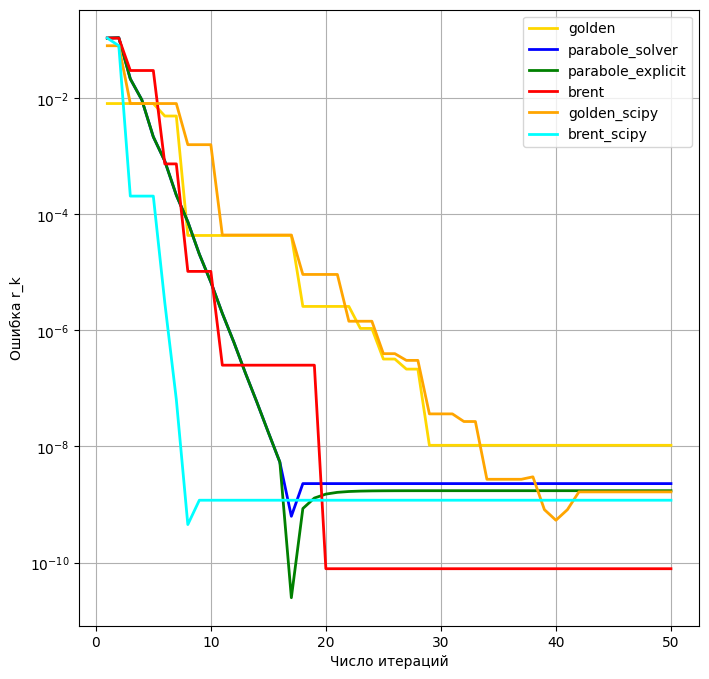

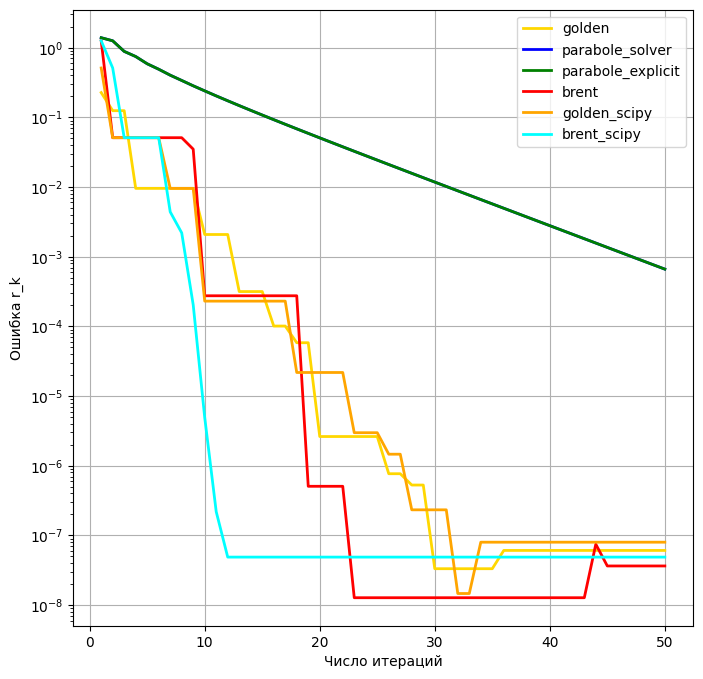

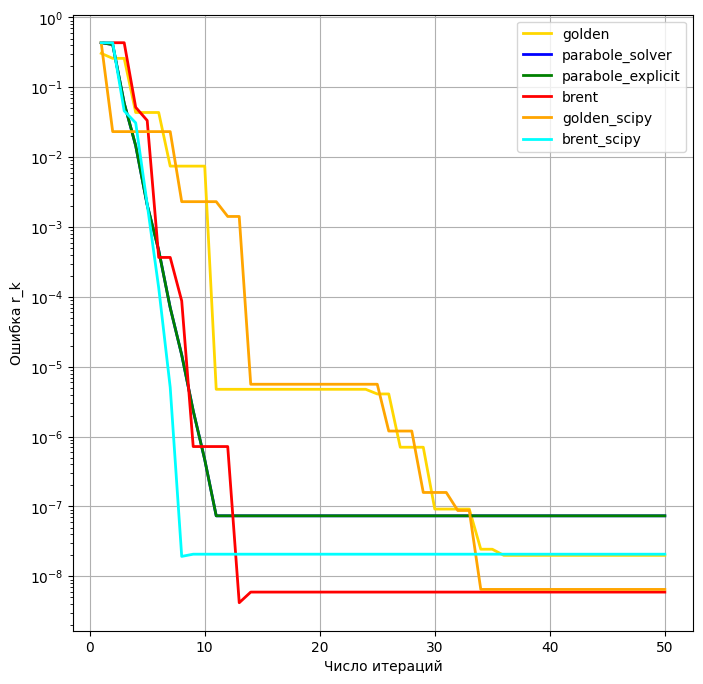

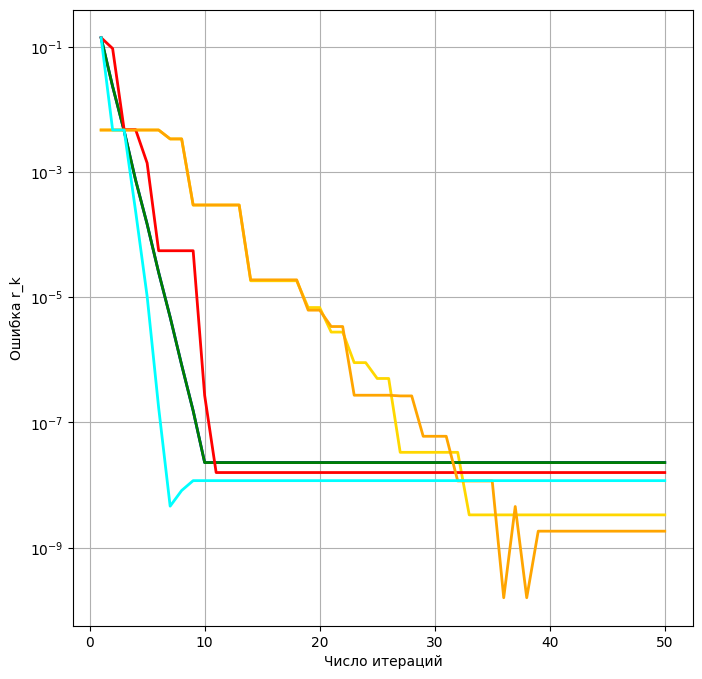

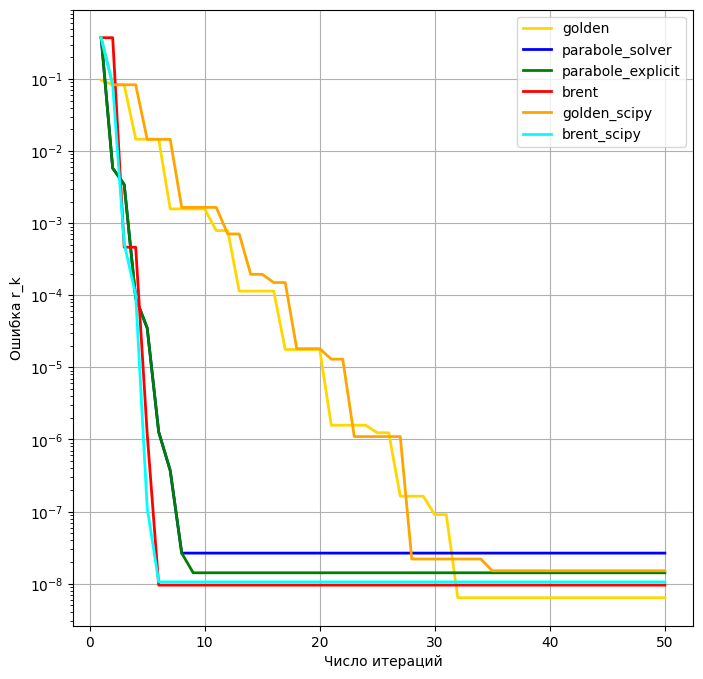

In [7]:
f1 = ("f1", lambda x: -5*x**5 + 4*x**4 - 12*x**3 + 11*x**2 - 2*x + 1, -0.5, 0.5, 0.1098599150914108)
f2 = ("f2", lambda x: -np.log(x-2)**2 + np.log(10-x)**2 - x**0.2, 6, 9.9, 9.206243176034041)
f3 = ("f3", lambda x: -3*x*np.sin(0.75*x) + np.exp(-2*x), 0, 2*np.pi, 2.706475576579055)
f4 = ("f4", lambda x: np.exp(3*x) + 5*np.exp(-2*x), 0, 1, 0.2407945558649553)
f5 = ("f5", lambda x: 0.2*x*np.log(x) + (x-2.3)**2, 0.5, 2.5, 2.124639762681344)
test_cases = [f1, f2, f3, f4, f5]
methods = ["golden", "parabole_solver", "parabole_explicit", "brent", "golden_scipy", "brent_scipy"]
colors = ["gold", "blue", "green", "red", "orange", "cyan"]
Ns = range(1, 51)

epsilon = 1e-7
for fname, f, a, b, true_min in [f1, f2, f3]:
  c = (a+b)/2+1e-6
  print(fname)

  fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize = (8,8))
  ax.set_xlabel("Число итераций")
  ax.set_ylabel("Ошибка r_k")
  ax.grid(True)

  for method_name, color in zip(methods, colors):
    print('{}: x_min = {}, f_min = {}'.format(method_name, *optimise(f, a, b, epsilon, 100, c, method_name)))
    errors = [abs(optimise(f, a, b, epsilon, N, c, method_name)[0] - true_min) for N in Ns]
    ax.semilogy(Ns, errors, label = method_name, c=color, linewidth=2)

  print("="*10)
  ax.legend(loc="upper right")
  plt.savefig(f'{fname}_convergence_all.pdf', bbox_inches='tight')

for fname, f, a, b, true_min in [f4]:
  c = b - (b - a) / ((1 + 5**0.5) / 2)+1e-6
  print(fname)

  fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize = (8,8))
  ax.set_xlabel("Число итераций")
  ax.set_ylabel("Ошибка r_k")
  ax.grid(True)

  for method_name, color in zip(methods, colors):
    print('{}: x_min = {}, f_min = {}'.format(method_name, *optimise(f, a, b, epsilon, 100, c, method_name)))
    errors = [abs(optimise(f, a, b, epsilon, N, c, method_name)[0] - true_min) for N in Ns]
    ax.semilogy(Ns, errors, label = method_name, c=color, linewidth=2)

  for fname, f, a, b, true_min in [f5]:
    c = b-1e-4
    print(fname)

    fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize = (8,8))
    ax.set_xlabel("Число итераций")
    ax.set_ylabel("Ошибка r_k")
    ax.grid(True)

    for method_name, color in zip(methods, colors):
      print('{}: x_min = {}, f_min = {}'.format(method_name, *optimise(f, a, b, epsilon, 100, c, method_name)))
      errors = [abs(optimise(f, a, b, epsilon, N, c, method_name)[0] - true_min) for N in Ns]
      ax.semilogy(Ns, errors, label = method_name, c=color, linewidth=2)


  print("="*10)
  ax.legend(loc="upper right")
  plt.savefig(f'{fname}_convergence_all.pdf', bbox_inches='tight')

Метод золотого сечения сходится в целом медленнее всех алгоритмов. Сходимость у него линейная (до тех пор, пока он не достигает критерия остановки по точности).

Метод Брента, как наиболее "совершенный", либо сходится быстрее других методов, либо не отстаёт. Является комбинацией метода парабол и золотого сечения и показывает соответствующую сходимость в зависимости от обстоятельств.

Метод парабол имеет сверхлинейную сходимость, но неустойчив.

Стоит заметить, что разные реализации метода парабол действительно иногда ведут себя по-разному. Так, для первой функции реализация через явную формулу из-за своей специфики даже "разбегается", **увеличивая ошибку** при последующих итерациях, в то время как солвер справляется нормально.

Так же мы заметили, что метод парабол обладает огромным недостатком: при достаточной близости трёх точек, будь то из-за самой функции (наличия плоского участка) или слишком высокой точности, алгоритм перестаёт работать. Из-за этого он не применим при $\varepsilon = 10^{-8}$ (корень из машинной точности) и меньше, и поэтому в коде используется $\varepsilon = 10^{-7}$.

Встроенное золотое сечение работает сходно с нашим. Встроенный метод Брента сходится значительно быстрее любых других представленных методов.

###5. Мультимодальные функции

Выше мы анализировали сходимость методов нулевого порядка. Для этой цели были использованы функции, (на промежутках) обладающие одним важным свойством &ndash; **унимодальностью**, функция сначала убывает, потом возрастает и имеет один локальный минимум. Теперь проверим, как различные алгоритмы справляются с трудностями, вызванными **мультимодальными** функциями.

g1
golden: x_min = 0.2445004502038876, f_min = -0.08535192522731593
parabole_solver: x_min = 0.5313265536611611, f_min = 0.017992498164783433
parabole_explicit: x_min = 0.531326553662222, f_min = 0.017992498164783488
brent: x_min = 0.24450045136490028, f_min = -0.08535192522731597
g2
golden: x_min = 0.9029986936897142, f_min = -0.39748064389243276
parabole_solver: x_min = 0.9029986791722887, f_min = -0.3974806438924331
parabole_explicit: x_min = 0.9029986858961732, f_min = -0.39748064389243315
brent: x_min = 0.9029986840926364, f_min = -0.3974806438924332
g3
golden: x_min = 0.30240088412535576, f_min = -53.0911247698415
parabole_solver: x_min = 0.30240088870779563, f_min = -53.09112476984152
parabole_explicit: x_min = 0.3024008869590313, f_min = -53.09112476984152
brent: x_min = 0.30240088694157025, f_min = -53.09112476984153


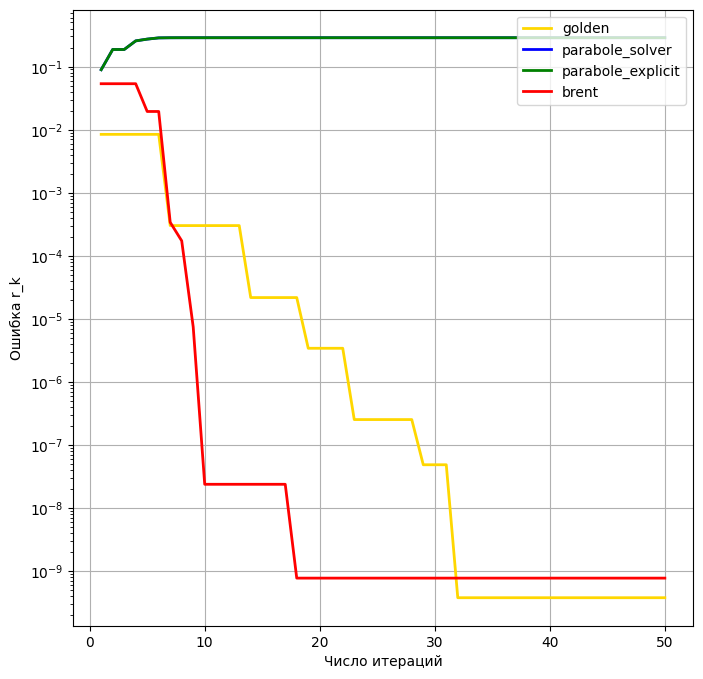

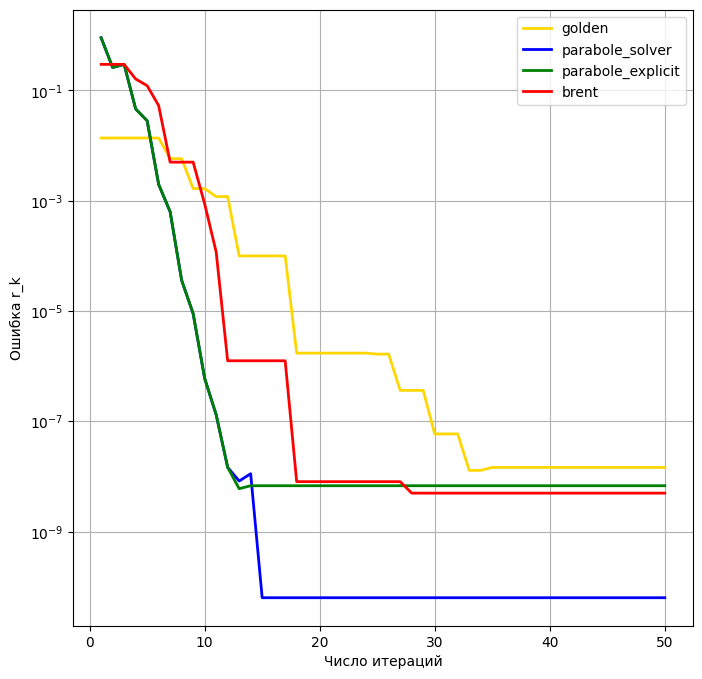

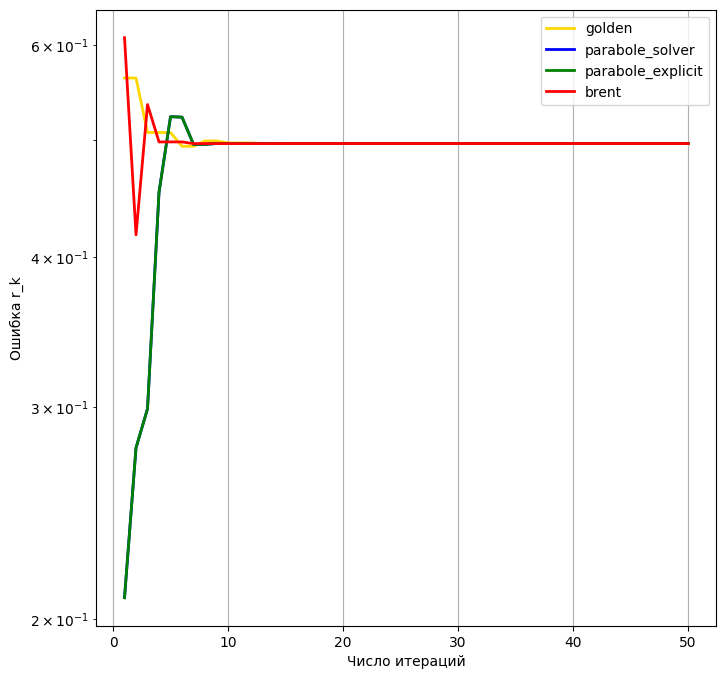

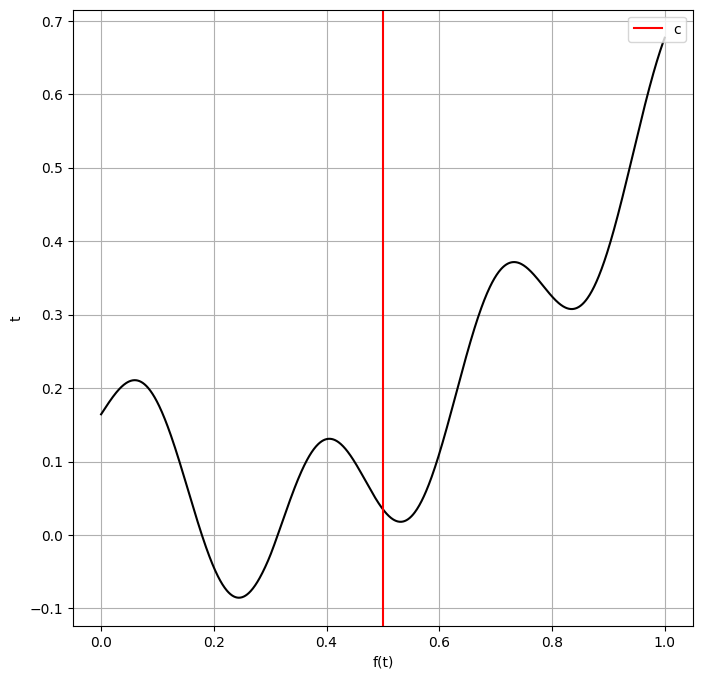

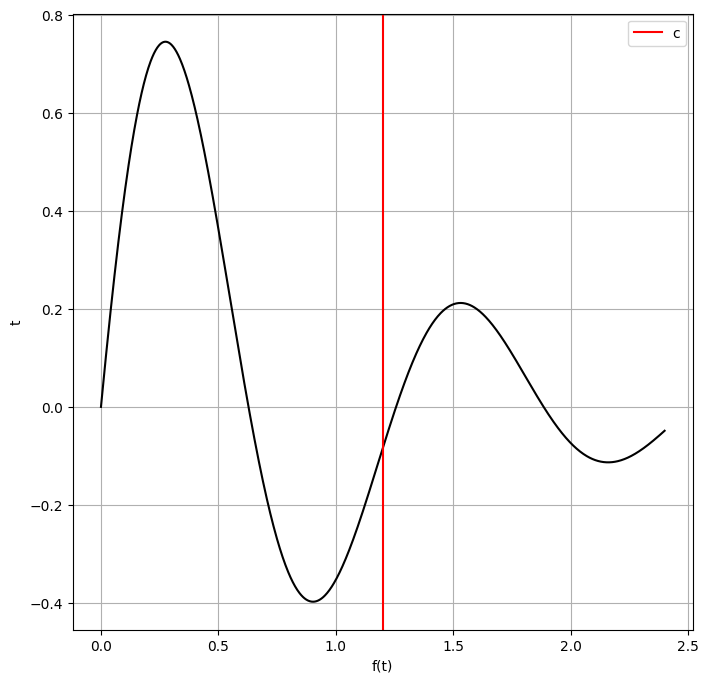

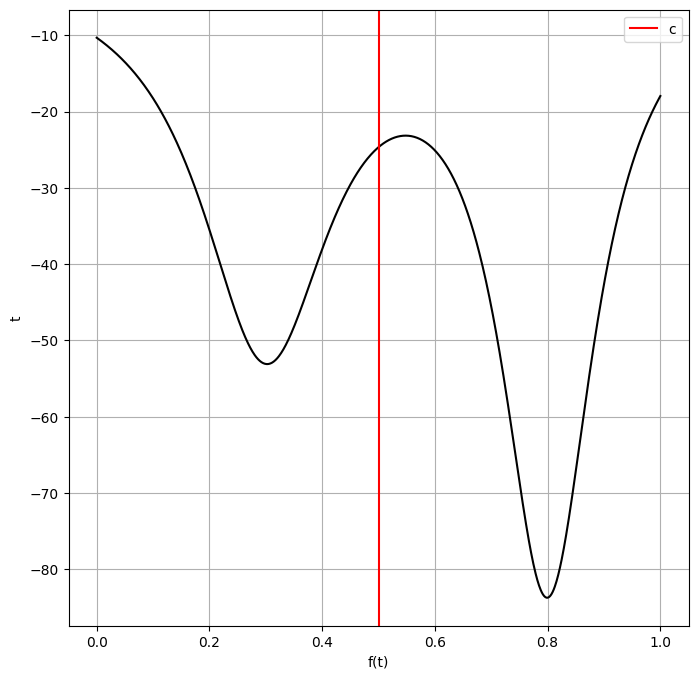

In [8]:
g1 = ("g1", lambda x: (np.abs(x-0.3))**1.5 + 0.1*np.sin(20*x), 0, 1, 0.2445004505851458)
g2 = ("g2", lambda x: np.exp(-x)*np.sin(5*x), 0, 2.4, 0.9029986791090862)
g3 = ("g3", lambda x: -1/((x-0.3)**2+0.02)-0.8/((x-0.8)**2+0.01), 0, 1, 0.7991385274847752)

test_cases_multi = [g1, g2, g3]
methods = ["golden", "parabole_solver", "parabole_explicit", "brent"]
colors = ["gold", "blue", "green", "red"]
Ns = range(1, 51)

epsilon = 1e-7
for fname, f, a, b, true_min in [g1, g2, g3]:
  c = (a+b)/2+1e-6
  print(fname)

  fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize = (8,8))
  ax.set_xlabel("Число итераций")
  ax.set_ylabel("Ошибка r_k")
  ax.grid(True)

  for method_name, color in zip(methods, colors):
    print('{}: x_min = {}, f_min = {}'.format(method_name, *optimise(f, a, b, epsilon, 100, c, method_name)))
    errors = [abs(optimise(f, a, b, epsilon, N, c, method_name)[0] - true_min) for N in Ns]
    ax.semilogy(Ns, errors, label = method_name, c=color, linewidth=2)

  print("="*10)
  ax.legend(loc="upper right")
  plt.savefig(f'{fname}_convergence_all.pdf', bbox_inches='tight')

for fname, f, a, b, true_min in [g1, g2, g3]:
  c = (a+b)/2+1e-6

  fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize = (8,8))
  ax.set_xlabel("f(t)")
  ax.set_ylabel("t")
  ax.grid(True)

  t = np.linspace(a, b, 1000)
  ax.plot(t, f(t), c="black")
  ax.axvline(c, c="red", label="c")

  ax.legend(loc="upper right")
  plt.savefig(f'{fname}_graph.pdf', bbox_inches='tight')



Для первой функции метод парабол "застрял" в локальном минимуме, в то время как остальные нашли глобальный.

Для второй функции все методы попали в глобальный минимум, но параболы нашли минимум с достаточно большой ошибкой.

Для третьей функции все методы "застряли" в локальном минимуме.

Можно сделать вывод, что ни один из методов не способен в общем случае находить глобальный минимум и попадает в один из локальных минимумов в зависимости от начального приближения &ndash; в нашем случае $c$ выбрана как середина промежутка, которая, к примеру, оказалась ближе к левой "яме" третьей функции.

###Выводы

>Итак, мы рассмотрели различные методы оптимизации нулевого порядка.

>Метод золотого сечения медлителен, но работает стабильно.

>Метод парабол чаще расходится, но сходится быстрее метода золотого сечения.

>Метод Брента является наиболее совершенным методом, чаще всего показывая как лучшую скорость, так и надёжность.

>На мультимодальных функциях методы нулевого порядка легко могут застрять в минимумах, не являющихся глобальными, из-за принципа их работы, и результат определяется заданными начальными точками.

## Задание 2. Градиентный спуск

### Вспомогательные функции

In [9]:
# Построение Поверхностей
def make_3Dgraph(X, Y, Z, angles):
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    ax.view_init(elev=angles[0], azim=angles[1])

    # function
    ax.plot_surface(X, Y, Z, alpha=0.8, zorder=1)

    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    ax.set_title(r'Функция $f(x)$', pad=20, fontweight='bold')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


# Построение графиков траектории
def make_GD_trajectory_graphs(data_list, titles, angles):
    assert len(data_list) == 4, "Должно быть ровно 4 набора данных"

    fig = plt.figure(figsize=(12, 7))

    for i, data in enumerate(data_list):
        ax = fig.add_subplot(2, 2, i + 1, projection='3d')
        ax.view_init(elev=angles[0], azim=angles[1])

        # Surface
        ax.plot_surface(data['X'], data['Y'], data['Z'],
                        alpha=0.8, cmap='viridis', zorder=1)

        # Start pos
        ax.scatter(*data['x0'], color='purple', s=150,
                   edgecolors='black', linewidths=1.5,
                   zorder=10, label='Старт')

        # End pos
        ax.scatter(*data['x_opt'], color='red', s=150,
                   edgecolors='black', linewidths=1.5,
                   zorder=10, label='Оптимум')

        # Trajectory
        ax.plot(data['history'][:, 0], data['history'][:, 1],
                data['history'][:, 2],
                linewidth=2, color='orange',
                label='Траектория', zorder=5)

        ax.set_xlabel('X')
        ax.set_ylabel('Y')
        ax.set_zlabel('Z')
        ax.set_title(titles[i], pad=20, fontweight='bold')
        ax.grid(True, alpha=0.3)

        if i == 0:
            ax.legend()

    plt.tight_layout()
    plt.show()

# Построение графиков сходимости
def make_convergence_comparison_graph(params):
    plt.figure(figsize=(10, 6))

    for iterations, error_values, label in params:
        plt.plot(iterations, error_values, label=label, linewidth=2)

    plt.xlabel('Итерация k')
    plt.ylabel(r'$f(x_k) - f_{opt}$')
    plt.title('Сравнение скорости сходимости (Log пространство)')
    plt.yscale('log')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

### 1. Реализация методов

In [10]:
# Спуск с константой
def GD_constant(grad_f, x0, alpha, epsilon=0.001, max_iterations=2000):
    x_current = x0.copy()
    history_solution = [x_current.copy()]

    history_grad = []
    history_grad_norm = []

    for i in range(max_iterations):
        grad = grad_f(x_current)
        grad_norm = np.linalg.norm(grad)
        history_grad.append(grad.copy())
        history_grad_norm.append(grad_norm)

        if grad_norm < epsilon:
            break

        x_new = x_current - alpha * grad
        x_current = x_new
        history_solution.append(x_current.copy())

    return x_current, np.array(history_solution), np.array(history_grad), np.array(history_grad_norm)


# Спуск с адаптивным поиском L
def GD_adaptive_Lipschitz(f, grad_f, x0, L0, gamma, rho, epsilon=0.001, max_iterations=2000):

    assert gamma > 1, "gamma должен быть > 1"
    assert 0 < rho < 1, "rho не в (0, 1)"
    assert L0 > 0, "L0 должен быть положительным"

    x_current = x0.copy()
    L_current = L0
    history_solution = [x_current.copy()]

    history_grad = []
    history_grad_norm = []

    for i in range(max_iterations):

        grad = grad_f(x_current)
        grad_norm = np.linalg.norm(grad)
        history_grad.append(grad.copy())
        history_grad_norm.append(grad_norm)

        if grad_norm < epsilon:
            break

        f_current = f(x_current)

        inner_iter = 0
        while True:
            x_new = x_current - 1/L_current * grad

            if f(x_new) <= f_current - 1/(2 * L_current) * grad_norm**2:
                break
            else:
                L_current *= gamma  # gamma > 1

            inner_iter += 1
            if inner_iter > 100:
                raise RuntimeError(f"Не удалось подобрать L на итерации {i}")

        history_solution.append(x_new.copy())
        x_current = x_new
        L_current *= rho  # rho < 1

    return x_current, np.array(history_solution), np.array(history_grad), np.array(history_grad_norm)


# Спуск с одномерной оптимизацией
def GD_and_ZeroOpt(f, grad_f, x0, a, b, c, tol=1e-6, N=50, epsilon=0.001, max_iterations=2000):
    x_current = x0.copy()
    history_solution = [x_current.copy()]

    history_grad = []
    history_grad_norm = []

    for i in range(max_iterations):
        grad = grad_f(x_current)
        grad_norm = np.linalg.norm(grad)
        history_grad.append(grad.copy())
        history_grad_norm.append(grad_norm)

        if grad_norm < epsilon:
            break

        f_along_beta = lambda beta: f(x_current - beta * (grad / grad_norm))
        beta_opt, f_val = parabole_explicit(f_along_beta, a, b, tol, N, c)
        beta = max(beta_opt, 1e-8)
        alpha = beta / grad_norm

        x_new = x_current - alpha * grad

        x_current = x_new
        history_solution.append(x_current.copy())

    return x_current, np.array(history_solution), np.array(history_grad), np.array(history_grad_norm)


# Спуск с backtracking
def GD_backtracking(f, grad_f, x0, alpha0, c1, c2, rho, epsilon=0.001, max_iterations=2000):

    assert 0 < c2 < 1, "c2 не в (0, 1)"
    assert 0 < c1 < c2, "c1 не в (0, 1)"
    assert 0 < rho < 1, "rho не в (0, 1)"

    x_current = x0.copy()
    history_solution = [x_current.copy()]

    history_grad = []
    history_grad_norm = []

    for i in range(max_iterations):
        alpha_current = alpha0
        grad = grad_f(x_current)
        grad_norm = np.linalg.norm(grad)
        history_grad.append(grad.copy())
        history_grad_norm.append(grad_norm)

        if grad_norm < epsilon:
            break

        inner_iter = 0
        phi0 = f(x_current)
        grad_dot_d = -grad_norm**2  # dot_product(grad, -grad)
        while True:
            x_new = x_current - alpha_current * grad
            phi_new = f(x_new)  # phi(a) = f(x_k + a*d)
            grad_new = grad_f(x_new)

            armijo = phi_new <= phi0 + c1 * alpha_current * grad_dot_d  # Armijo cond. (grad_dot_d = -grad_norm**2)
            wolfe = abs(grad_new.dot(-grad)) <= c2 * abs(grad_dot_d)  # Strong Wolfe cond.

            if armijo and wolfe:
                break

            alpha_current *= rho

            inner_iter += 1
            if inner_iter > 100:
                raise RuntimeError(f"Не удалось подобрать alpha на итерации {i}")

        x_current = x_new.copy()
        history_solution.append(x_current.copy())

    return x_current, np.array(history_solution), np.array(history_grad), np.array(history_grad_norm)

### 2. Применение методов на произвольной функции $f(x) = x^TAx + b^Tx$,

Зададим следующие матрицы для функции $f(x)$:

In [11]:
A = np.array([[3, 2],
              [2, 4]
              ])

b = np.array([5,
              6])

где $x \in R^2$, $b \in R^2$, $A \in R^{2\times2}$ - положительно определённая матрица

Задание функции $f(x)$, а также её аналитического градиента:

In [12]:
def f(x: np.ndarray) -> np.ndarray:
    return x.T @ A @ x + b.T @ x


def grad_f(x: np.ndarray) -> np.ndarray:
    return (A + A.T) @ x + b

#### График функции $f(x)$

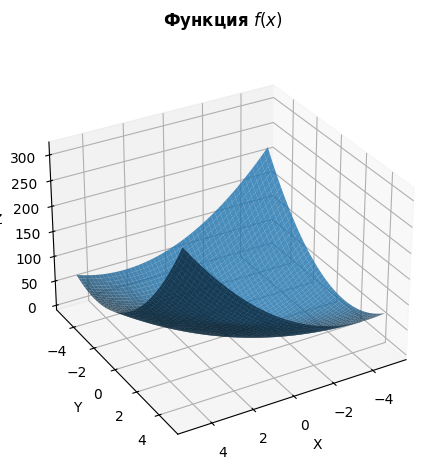

In [13]:
x = np.arange(-5, 5, 0.1)
y = np.arange(-5, 5, 0.1)
X, Y = np.meshgrid(x, y, indexing='ij')
Z = np.array([f(p) for p in np.stack([X.ravel(), Y.ravel()], axis=1)]).reshape(X.shape)

make_3Dgraph(X, Y, Z, (30, 60))

Данная функция является *Липшецевой*, а также *сильно выпуклой*. Это следует из того, как она задаётся в условии.

#### Применение градиентного спуска со стратегией постоянного коэффицента $\alpha = \frac{1}{L}$ для функции $f(x)$

Вычислим константы $L$ и $\mu$. Взяв градиент от градиента функции $f(x)$ получим матрицу Гессе. Отсюда $L = \max(\lambda_i)$, а $\mu = \min(\lambda_i)$:

In [14]:
Hessian_f = 2 * A
spectre = np.linalg.eigvalsh(Hessian_f)

L = np.max(spectre)
mu = np.min(spectre)

Перейдём к анализу данной стратегии. С помощью констант ниже можно получить следующие оценки:

Оценка минимального квадрата нормы градиента за k итераций:
$$g_k = min||\nabla f(x_k)||^2 \le \frac{2L(f_0 - f_{opt})}{k + 1}$$

Оценка разницы истинного *оптимума* функции и её значения на $k$-ой итерации:
$$f_k - f_{opt} \le (1 - \frac{\mu}{L})^{k}(f_0 - f_{opt})$$

Код ниже реализует данные оценки, а также строит график сходимости для рассматриваемой стратегии для 3 значений $\alpha$:


Оценка сходимости градиента (gk = min ||grad||^2):
    Итерация k    Оценка g_k           g_k  Текущая ||grad||^2  g_k <= оценки?
0            0  2997.6769661  2989.0000000        2989.0000000            True
1            1  1498.8384831     1.6637733           1.6637733            True
2            2   999.2256554     0.9144310           0.9144310            True
3            3   749.4192415     0.5025829           0.5025829            True
4            4   599.5353932     0.2762260           0.2762260            True
5            5   499.6128277     0.1518173           0.1518173            True
6            6   428.2395666     0.0834407           0.0834407            True
7            7   374.7096208     0.0458601           0.0458601            True
8            8   333.0752185     0.0252053           0.0252053            True
9            9   299.7676966     0.0138531           0.0138531            True
10          10   272.5160878     0.0076139           0.0076139            True


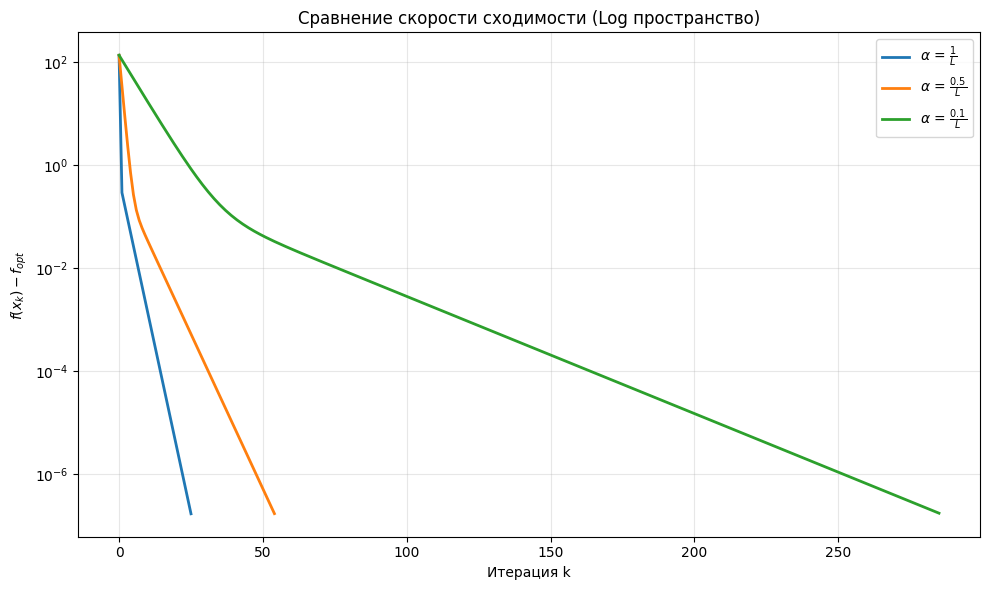

In [15]:
x0 = np.array([3, 3])
x_opt, history_sol, history_grad, history_grad_norm = GD_constant(grad_f, x0=x0, alpha=1/L)


# analytical evaluations:
f_0 = f(x0)
f_true_opt = f(-np.linalg.solve(A + A.T, b))

# Оценка квадрата нормы градиента
#-----------------------------------------------------------------------------------------------------------------------
inequation_gk = lambda k: 2 * L * (f_0 - f_true_opt) / (k + 1)
min_grad_norm_sq = [np.min(history_grad_norm[:k+1]**2) for k in range(len(history_grad_norm))]
evaluation_gk = [np.round(inequation_gk(k), 7) for k in range(len(history_sol))]

df_gk = pd.DataFrame({
    "Итерация k": range(len(history_grad)),
    "Оценка g_k": evaluation_gk,
    "g_k": min_grad_norm_sq,
    "Текущая ||grad||^2": history_grad_norm**2,
    "g_k <= оценки?": min_grad_norm_sq <= evaluation_gk
})

print("\nОценка сходимости градиента (gk = min ||grad||^2):")
print(df_gk)
#-----------------------------------------------------------------------------------------------------------------------

# Оценка разницы f_k - f_opt после k итераций
#-----------------------------------------------------------------------------------------------------------------------
f_k_vs_f_opt_inequation = lambda k: (1 - mu/L)**k * (f_0 - f_true_opt)
evaluation_f_k_vs_f_opt = [f_k_vs_f_opt_inequation(k) for k in range(len(history_sol))]
f_k_vs_f_opt = [f(history_sol[k]) - f_true_opt for k in range(len(history_sol))]

df_f_k_vs_f_opt = pd.DataFrame({"Итерация k": range(len(history_sol)),
                                "Оценка f_k - f_opt": evaluation_f_k_vs_f_opt,
                                "f_k - f_opt": f_k_vs_f_opt,
                                "f_k - f_opt <= оценка?": f_k_vs_f_opt <= evaluation_f_k_vs_f_opt})
print(f"\nОценка невязки после k итераций (Оценка для k итерации):")
print(df_f_k_vs_f_opt)
#-----------------------------------------------------------------------------------------------------------------------

# Графики скорости сходимости
x_opt1, history_sol1, history_grad1, history_grad_norm1 = GD_constant(grad_f, x0=x0, alpha=1/L)
x_opt2, history_sol2, history_grad2, history_grad_norm2 = GD_constant(grad_f, x0=x0, alpha=0.5/L)
x_opt3, history_sol3, history_grad3, history_grad_norm3 = GD_constant(grad_f, x0=x0, alpha=0.1/L)

error_values1 = np.array([f(x) for x in history_sol1]) - f_true_opt
error_values2 = np.array([f(x) for x in history_sol2]) - f_true_opt
error_values3 = np.array([f(x) for x in history_sol3]) - f_true_opt

params = [
    (range(len(error_values1)), error_values1, r'$\alpha$ = $\frac{1}{L}$'),
    (range(len(error_values2)), error_values2, r'$\alpha$ = $\frac{0.5}{L}$'),
    (range(len(error_values3)), error_values3, r'$\alpha$ = $\frac{0.1}{L}$')
]

make_convergence_comparison_graph(params)

##### Выводы:

> Как мы можем наблюдать по Дата фреймам, оценки действительно выполняются, что подтверждает теорию, а также верность реализации. На графике сходимости, после некоторого значения, наблюдается **линейная сходимость**. Это объясняется сильной выпуклостью функции. Данное условие улучшает стратегию выбора $\alpha = \frac{1}{L}$, дающую **сублинейную сходимость**, что и приводит к возникновению сходимости более высокого порядка. Выбор других значений константы $\alpha$ приводит к сильному увеличению количества итераций, а также в начале к поведению, похожему на сублинейную сходимость.

#### Применение градиентного спуска со всеми рассматриваемыми стратегиями:

Применим все стратегии градиентного спуска с некоторым начальным условием поочерёдно:

In [16]:
x0 = np.array([6, 7])
f_true_opt = f(-np.linalg.solve(A + A.T, b))

# Константа
Hessian_f = 2 * A
L = np.max(np.linalg.eigvalsh(Hessian_f))
x_opt_constant, history_sol_constant = GD_constant(grad_f, x0=x0, alpha=1/L)[:2]

# Адаптивный поиск константы Липшица
x_opt_adapt_Lipschitz, history_sol_adapt_Lipschitz = GD_adaptive_Lipschitz(f, grad_f, x0=x0,
                                                                                 L0=1.3, gamma=1.7, rho=0.2)[:2]

# Через одномерную оптимизацию
x_opt_ZeroOpt, history_sol_ZeroOpt = GD_and_ZeroOpt(f, grad_f, x0=x0, a=0, b=0.001, c=0.01)[:2]

# Backtracking
x_opt_backtracking, history_sol_backtracking = GD_backtracking(f, grad_f, x0=x0,
                                                               alpha0=0.4, c1=0.1, c2=0.7, rho=0.9)[:2]

Построим графики сходимости для каждого спуска:

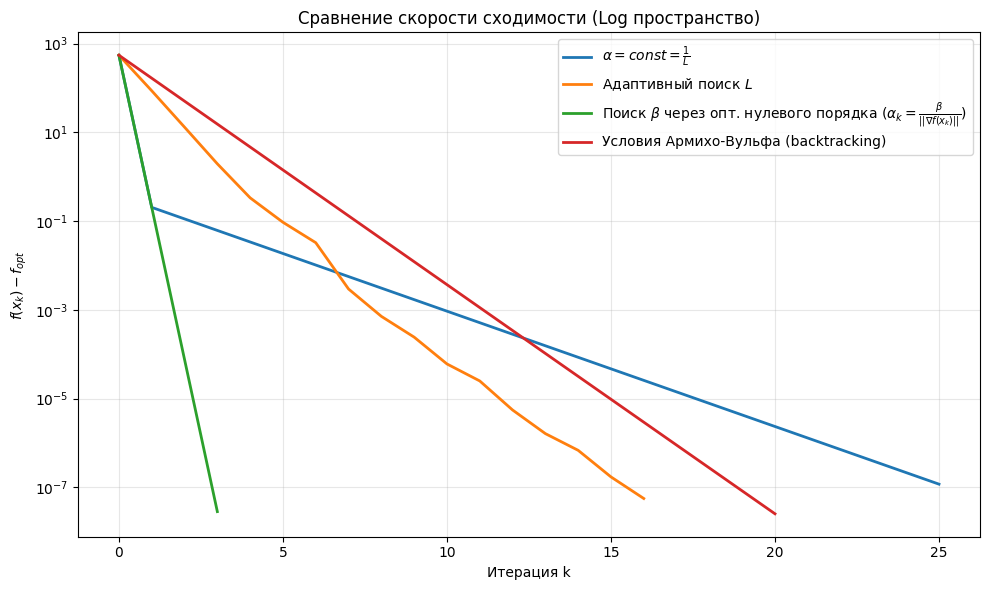

In [17]:
error_values_constant = np.array([f(x) for x in history_sol_constant]) - f_true_opt
error_values_adapt_Lipschitz = np.array([f(x) for x in history_sol_adapt_Lipschitz]) - f_true_opt
error_values_ZeroOpt = np.array([f(x) for x in history_sol_ZeroOpt]) - f_true_opt
error_values_backtracking = np.array([f(x) for x in history_sol_backtracking]) - f_true_opt


params = [
    (range(len(error_values_constant)), error_values_constant, r'$\alpha = const = \frac{1}{L}$'),
    (range(len(error_values_adapt_Lipschitz)), error_values_adapt_Lipschitz, r'Адаптивный поиск $L$'),
    (range(len(error_values_ZeroOpt)), error_values_ZeroOpt, r'Поиск $\beta$ через опт. нулевого порядка ($\alpha_k = \frac{\beta}{||\nabla f(x_k)||}$)'),
    (range(len(error_values_backtracking)), error_values_backtracking, 'Условия Армихо-Вульфа (backtracking)'),
]

make_convergence_comparison_graph(params)

Теперь построим траектории спуска по поверхности $f(x)$ для каждого из методов:

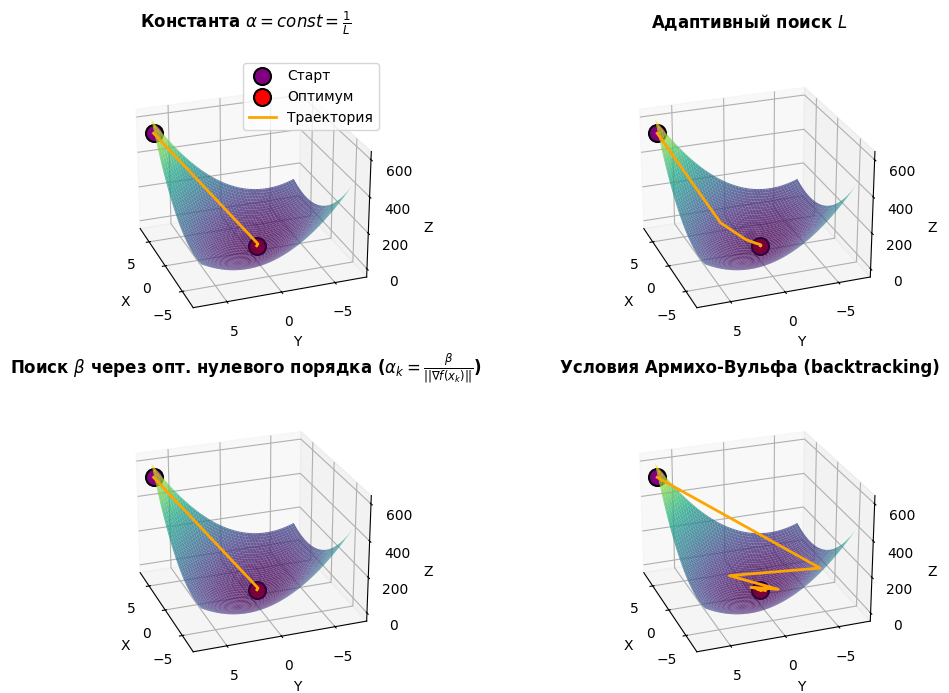

In [18]:
x = np.arange(-7, 7, 0.1)
y = np.arange(-7, 7, 0.1)
X, Y = np.meshgrid(x, y, indexing='ij')
Z = np.array([f(p) for p in np.stack([X.ravel(), Y.ravel()], axis=1)]).reshape(X.shape)

z_values = np.apply_along_axis(f, 1, history_sol_constant)
history_sol_constant_3d = np.column_stack([history_sol_constant, z_values])

z_values = np.apply_along_axis(f, 1, history_sol_adapt_Lipschitz)
history_sol_adapt_Lipschitz_3d = np.column_stack([history_sol_adapt_Lipschitz, z_values])

z_values = np.apply_along_axis(f, 1, history_sol_ZeroOpt)
history_sol_ZeroOpt_3d = np.column_stack([history_sol_ZeroOpt, z_values])

z_values = np.apply_along_axis(f, 1, history_sol_backtracking)
history_sol_backtracking_3d = np.column_stack([history_sol_backtracking, z_values])

data_list = [
    {'X': X, 'Y': Y, 'Z': Z, 'x0': np.array([*x0, f(x0)]),
     'x_opt': np.array([*x_opt_constant, f(x_opt_constant)]), 'history': history_sol_constant_3d},

    {'X': X, 'Y': Y, 'Z': Z, 'x0': np.array([*x0, f(x0)]),
     'x_opt': np.array([*x_opt_adapt_Lipschitz, f(x_opt_adapt_Lipschitz)]), 'history': history_sol_adapt_Lipschitz_3d},

    {'X': X, 'Y': Y, 'Z': Z, 'x0': np.array([*x0, f(x0)]),
     'x_opt': np.array([*x_opt_ZeroOpt, f(x_opt_ZeroOpt)]), 'history': history_sol_ZeroOpt_3d},

    {'X': X, 'Y': Y, 'Z': Z, 'x0': np.array([*x0, f(x0)]),
     'x_opt': np.array([*x_opt_backtracking, f(x_opt_backtracking)]), 'history': history_sol_backtracking_3d},
]

titles = [
    r'Константа $\alpha = const = \frac{1}{L}$',
    r'Адаптивный поиск $L$',
    r'Поиск $\beta$ через опт. нулевого порядка ($\alpha_k = \frac{\beta}{||\nabla f(x_k)||}$)',
    'Условия Армихо-Вульфа (backtracking)'
]

make_GD_trajectory_graphs(data_list, titles, (25, 160))

##### Выводы:

> Для каждого метода можем наблюдать линейную сходимость, что согласуется с теорией. Самой долгой (в смысле количества итераций) оказалась стратегия с постоянным коэффициентом $\alpha = L$. Данный пример отлично демонстрирует, что адаптивный поиск константы $L$ может схоходится заметно быстрее, чем при выборе реальной $L$. Самым эффективным оказался методот с использованием одномерной оптимизации для поиска нужной $\alpha$, но в то же время он является и крайне требовательным в плане ресурсов. По графикам траектории мы можем наблюдать, как шёл наш спуск. Крайне интересным является траектория со стратегией Армихо-Вульфа, в которой спуск шёл "прыжками из стороны в сторону".

### 3. Оптимизация функции Розенброка

Попробуем найти оптимум с помощью градиентного спуска для функции Розенброка.

Аналитическим способом найдём её градиент, а также матрицу Гессе:

In [19]:
def f_rozenbrock(x: np.ndarray) -> np.ndarray:
    x1, x2 = x[0], x[1]
    return (1 - x1)**2 + 100 * (x2 - x1**2)**2


def grad_f_rozenbrock(x: np.ndarray) -> np.ndarray:
    x1, x2 = x[0], x[1]
    return np.array([-2 * (1 - x1) - 400 * (x2 - x1**2) * x1, 200 * (x2 - x1**2) * x1])


def hessian_f_rozenbrock(x: np.ndarray) -> np.ndarray:
    x1, x2 = x[0], x[1]
    d2f_dxdx = 2 - 400*x2 + 1200*x1**2
    d2f_dxdy = -400*x1
    d2f_dydx = -400*x1
    d2f_dydy = 200
    return np.array([
        [d2f_dxdx, d2f_dxdy],
        [d2f_dydx, d2f_dydy]
    ])

#### Исследование функции Розенброка на Липшевость и выпуклость/сильную выпуклость

Можем наблюдать, что Гессиан зависит от $x^2$ и $y$. Видим, что его собственные значения неограниченно растут при удалении от начала координат. Следовательно, не существует глобальной константы Липшица  $L$ для градиента по причине роста максимального собственного числа.

C выпуклостью/сильной выпуклостью похожий момент. Если посчитаем определитель матрицы Гессе, то получим
$$\det(\nabla^2 f(x)) = 400 + 80000(x^2 - y)$$
Отсюда видим, что второй главный минор матрицы, равный определителю, может быть отрицательным, поэтому Гессиан не является положительно определённым, откуда следует отсутсвие выпуклости нашей функции на всей области определения, а значит не может быть и строгой выпуклости.

#### График функеции Розенброка

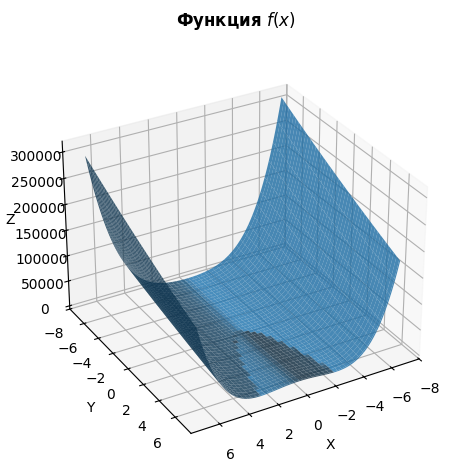

In [20]:
x = np.arange(-7, 7, 0.1)
y = np.arange(-7, 7, 0.1)
X, Y = np.meshgrid(x, y, indexing='ij')
Z = np.array([f_rozenbrock(p) for p in np.stack([X.ravel(), Y.ravel()], axis=1)]).reshape(X.shape)

make_3Dgraph(X, Y, Z, (30, 60))

#### Применение всех методов к функции Розенброка


##### Результаты и Графики сходимости каждой стратегии:

Графики при max_iterations = 2000

   Итераций      Результат работы                Ошибка
0      2000  [2.445483, 5.983071]  [1.445483, 4.983071]
1      2000  [2.499113, 6.248502]  [1.499113, 5.248502]
2       493  [1.001108, 1.002222]  [0.001108, 0.002222]
3      2000  [2.279506, 5.197636]  [1.279506, 4.197636]


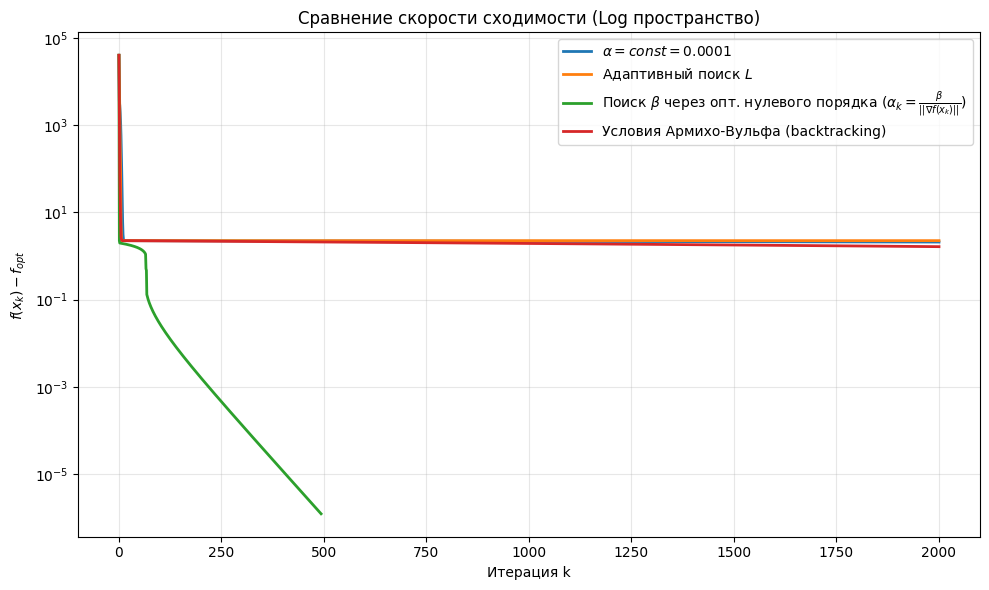

In [21]:
x0 = np.array([5, 5])
x_true_opt = np.array([1, 1])
f_true_opt = f_rozenbrock(x_true_opt)  # Аналитический минимум

# Константа
x_opt_constant, history_sol_constant = GD_constant(grad_f_rozenbrock, x0=x0, alpha=0.0001)[:2]

# Адаптивный поиск константы Липшица
x_opt_adapt_Lipschitz, history_sol_adapt_Lipschitz = GD_adaptive_Lipschitz(f_rozenbrock, grad_f_rozenbrock, x0=x0, L0=0.001, gamma=1.7, rho=0.2)[:2]

# Через одномерную оптимизацию
x_opt_ZeroOpt, history_sol_ZeroOpt = GD_and_ZeroOpt(f_rozenbrock, grad_f_rozenbrock, x0=x0, a=0.1, b=0.2, c=0.3)[:2]

# Backtracking
x_opt_backtracking, history_sol_backtracking = GD_backtracking(f_rozenbrock, grad_f_rozenbrock, x0=x0, alpha0=0.01, c1=0.2, c2=0.6, rho=0.9)[:2]

error_values_constant = np.array([f_rozenbrock(x) for x in history_sol_constant]) - f_true_opt
error_values_adaptive_Lipschitz = np.array([f_rozenbrock(x) for x in history_sol_adapt_Lipschitz]) - f_true_opt
error_values_ZeroOpt = np.array([f_rozenbrock(x) for x in history_sol_ZeroOpt]) - f_true_opt
error_values_backtracking = np.array([f_rozenbrock(x) for x in history_sol_backtracking]) - f_true_opt


params = [
    (range(len(error_values_constant)), error_values_constant, r'$\alpha = const = 0.0001$'),
    (range(len(error_values_adaptive_Lipschitz)), error_values_adaptive_Lipschitz, r'Адаптивный поиск $L$'),
    (range(len(error_values_ZeroOpt)), error_values_ZeroOpt, r'Поиск $\beta$ через опт. нулевого порядка ($\alpha_k = \frac{\beta}{||\nabla f(x_k)||}$)'),
    (range(len(error_values_backtracking)), error_values_backtracking, 'Условия Армихо-Вульфа (backtracking)'),
]

iterations = [len(history_sol_constant) - 1, len(history_sol_adapt_Lipschitz) - 1,
              len(history_sol_ZeroOpt) - 1, len(history_sol_backtracking) - 1]
approx_opts = [ np.round(x_k, 6) for x_k in [x_opt_constant, x_opt_adapt_Lipschitz, x_opt_ZeroOpt, x_opt_backtracking]]
error = [np.round(np.abs(x_true_opt - x_k), 6) for x_k in approx_opts]

df_results = pd.DataFrame({"Итераций": iterations, "Результат работы": approx_opts, "Ошибка": error})
print(df_results)

make_convergence_comparison_graph(params)

Графики при max_iterations = 12

   Итераций      Результат работы                Ошибка
0        12  [2.495774, 6.250617]  [1.495774, 5.250617]
1        12  [2.499113, 6.248502]  [1.499113, 5.248502]
2        12   [2.37558, 5.654999]   [1.37558, 4.654999]
3        12   [2.498805, 6.24592]   [1.498805, 5.24592]


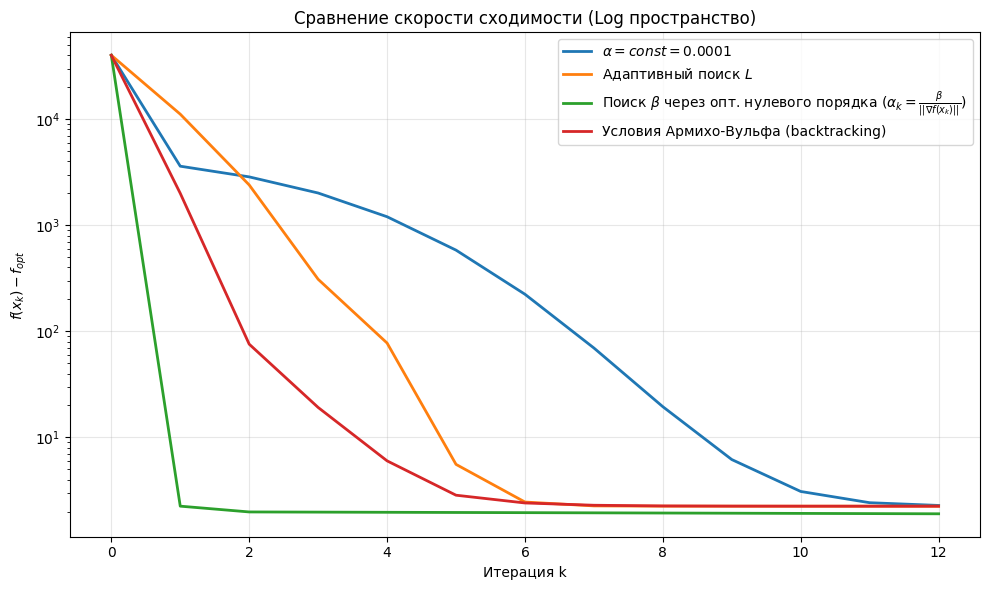

In [22]:
x0 = np.array([5, 5])
x_true_opt = np.array([1, 1])
f_true_opt = f_rozenbrock(x_true_opt)  # Аналитический минимум

# Константа
x_opt_constant, history_sol_constant = GD_constant(grad_f_rozenbrock, x0=x0, alpha=0.0001, max_iterations=12)[:2]

# Адаптивный поиск константы Липшица
x_opt_adapt_Lipschitz, history_sol_adapt_Lipschitz = GD_adaptive_Lipschitz(f_rozenbrock, grad_f_rozenbrock, x0=x0, L0=0.001, gamma=1.7, rho=0.2, max_iterations=12)[:2]

# Через одномерную оптимизацию
x_opt_ZeroOpt, history_sol_ZeroOpt = GD_and_ZeroOpt(f_rozenbrock, grad_f_rozenbrock, x0=x0, a=0.1, b=0.2, c=0.3, max_iterations=12)[:2]

# Backtracking
x_opt_backtracking, history_sol_backtracking = GD_backtracking(f_rozenbrock, grad_f_rozenbrock, x0=x0, alpha0=0.01, c1=0.2, c2=0.6, rho=0.9, max_iterations=12)[:2]

error_values_constant = np.array([f_rozenbrock(x) for x in history_sol_constant]) - f_true_opt
error_values_adaptive_Lipschitz = np.array([f_rozenbrock(x) for x in history_sol_adapt_Lipschitz]) - f_true_opt
error_values_ZeroOpt = np.array([f_rozenbrock(x) for x in history_sol_ZeroOpt]) - f_true_opt
error_values_backtracking = np.array([f_rozenbrock(x) for x in history_sol_backtracking]) - f_true_opt


params = [
    (range(len(error_values_constant)), error_values_constant, r'$\alpha = const = 0.0001$'),
    (range(len(error_values_adaptive_Lipschitz)), error_values_adaptive_Lipschitz, r'Адаптивный поиск $L$'),
    (range(len(error_values_ZeroOpt)), error_values_ZeroOpt, r'Поиск $\beta$ через опт. нулевого порядка ($\alpha_k = \frac{\beta}{||\nabla f(x_k)||}$)'),
    (range(len(error_values_backtracking)), error_values_backtracking, 'Условия Армихо-Вульфа (backtracking)'),
]

iterations = [len(history_sol_constant) - 1, len(history_sol_adapt_Lipschitz) - 1,
              len(history_sol_ZeroOpt) - 1, len(history_sol_backtracking) - 1]
approx_opts = [ np.round(x_k, 6) for x_k in [x_opt_constant, x_opt_adapt_Lipschitz, x_opt_ZeroOpt, x_opt_backtracking]]
error = [np.round(np.abs(x_true_opt - x_k), 6) for x_k in approx_opts]

df_results = pd.DataFrame({"Итераций": iterations, "Результат работы": approx_opts, "Ошибка": error})
print(df_results)

make_convergence_comparison_graph(params)

##### Построение траекторий

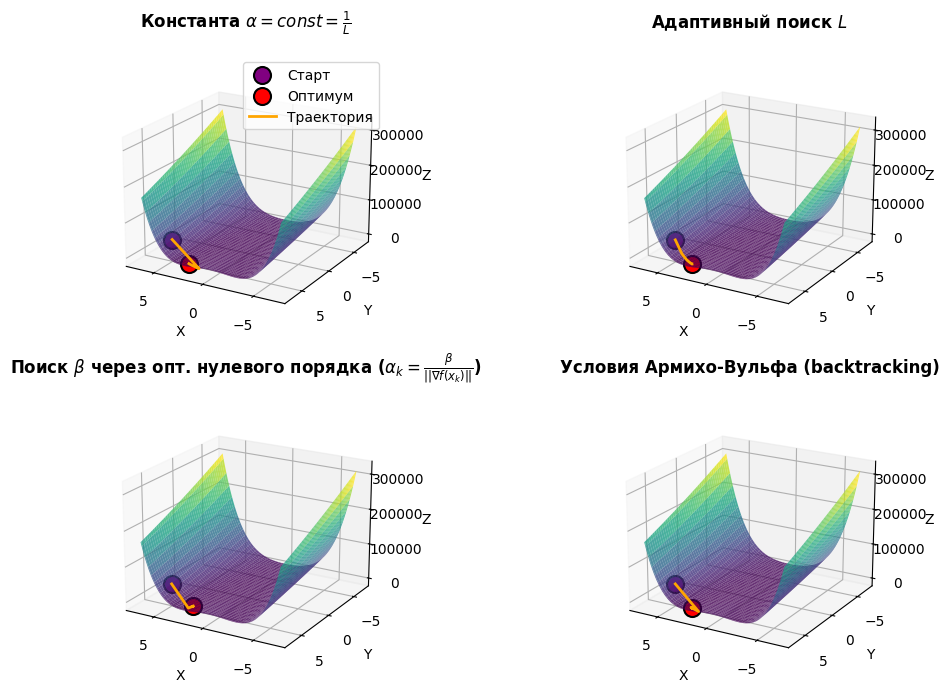

In [23]:
x = np.arange(-7, 7, 0.1)
y = np.arange(-7, 7, 0.1)
X, Y = np.meshgrid(x, y, indexing='ij')
Z = np.array([f_rozenbrock(p) for p in np.stack([X.ravel(), Y.ravel()], axis=1)]).reshape(X.shape)

z_values = np.apply_along_axis(f_rozenbrock, 1, history_sol_constant)
history_sol_constant_3d = np.column_stack([history_sol_constant, z_values])

z_values = np.apply_along_axis(f_rozenbrock, 1, history_sol_adapt_Lipschitz)
history_sol_adapt_Lipschitz_3d = np.column_stack([history_sol_adapt_Lipschitz, z_values])

z_values = np.apply_along_axis(f_rozenbrock, 1, history_sol_ZeroOpt)
history_sol_ZeroOpt_3d = np.column_stack([history_sol_ZeroOpt, z_values])

z_values = np.apply_along_axis(f_rozenbrock, 1, history_sol_backtracking)
history_sol_backtracking_3d = np.column_stack([history_sol_backtracking, z_values])

data_list = [
    {'X': X, 'Y': Y, 'Z': Z, 'x0': np.array([*x0, f_rozenbrock(x0)]),
     'x_opt': np.array([*x_opt_constant, f_rozenbrock(x_opt_constant)]), 'history': history_sol_constant_3d},

    {'X': X, 'Y': Y, 'Z': Z, 'x0': np.array([*x0, f_rozenbrock(x0)]),
     'x_opt': np.array([*x_opt_adapt_Lipschitz, f_rozenbrock(x_opt_adapt_Lipschitz)]), 'history': history_sol_adapt_Lipschitz_3d},

    {'X': X, 'Y': Y, 'Z': Z, 'x0': np.array([*x0, f_rozenbrock(x0)]),
     'x_opt': np.array([*x_opt_ZeroOpt, f_rozenbrock(x_opt_ZeroOpt)]), 'history': history_sol_ZeroOpt_3d},

    {'X': X, 'Y': Y, 'Z': Z, 'x0': np.array([*x0, f_rozenbrock(x0)]),
     'x_opt': np.array([*x_opt_backtracking, f_rozenbrock(x_opt_backtracking)]), 'history': history_sol_backtracking_3d},
]

titles = [
    r'Константа $\alpha = const = \frac{1}{L}$',
    r'Адаптивный поиск $L$',
    r'Поиск $\beta$ через опт. нулевого порядка ($\alpha_k = \frac{\beta}{||\nabla f(x_k)||}$)',
    'Условия Армихо-Вульфа (backtracking)'
]

make_GD_trajectory_graphs(data_list, titles, angles=(20, 120))

#### Выводы

> Функция Розенброка - это пример, в котором градиентный спуск "вязнет" и ближе к минимуму прогрес почти не ощущается. Все методы, за исключением стратегии через одномерную оптимизацию (вероятно, из-за хорошо выбранных параметров), требуют 2000+ итераций, чтобы сойтись. Функция Розенброка ни Липшицева, ни выпуклая на всей области определения, что усложняет задачу и требует дополнительных иссследований, а также грамотного выбора начальных условий. Стратегия с одномерной оптимизацией дала линейную сходимость. Со стратегиями Армихо-Вульфа и адаптивным поиском $L$ всё достаточно похоже - они лишь немного уступают стратегии с одномерной оптимизацией. Хуже всех себя показывает стратегия с постоянной $\alpha$.

## Задание 3. Построение траектории

Данное задание будет показано в программе Blender во время защиты работы :)